```Step 1. Importing and Reading Data``` 

I started by importing the modules needed to work with the data.

I then opened the PubMed results file and stored its contents in a variable so I could search through the article information.

In [11]:
import re
import csv

In [13]:
with open('../../Python/DataFiles/MapOfScience/pubmed_results.txt') as f:
    my_text = f.read()

```Step 2. Finding ZIP Codes```

I first cleaned up the text to make the addresses easier to work with.

Then, I searched through the PubMed file to find US ZIP codes. 

After finding them, I removed any repeats and put the ZIP codes in order.

I used the example solution posted on GitHub as a reference for re.sub() and sorted(set()). This helped me understand how to clean up the text and organize the ZIP codes.

In [14]:
my_text = re.sub(r'\n\s{6}', ' ', my_text)

In [39]:
zip_codes = re.findall(r'[A-Z]{2}\s(\d{5}), USA', my_text)
print(len(zip_codes))
print(zip_codes[:10])

5198
['02138', '02115', '02138', '02138', '02138', '02115', '02115', '02115', '02142', '02139']


In [40]:
unique_zips = sorted(set(zip_codes))
print(len(unique_zips))

462


```Step 3. Matching ZIP Codes to Coordinates```

I used the coordinates file to find the latitude and longitude for each ZIP code.

Next, I made a dictionary to keep track of each ZIP code and its location.

From there, I created four lists to organize the ZIP codes, their coordinates, and how many times each one showed up in the PubMed file.

I also used the example solution on GitHub as a reference to help me understand how to organize the coordinates into a dictionary and fill the four lists.

In [50]:
with open('../../Python/DataFiles/MapOfScience/zipcodes_coordinates.txt') as f:
    coordinates = list(csv.reader(f))

In [51]:
zip_coordinates = {}

for row in coordinates[1:]:
    zip_coordinates[row[0]] = [float(row[1]), float(row[2])]


In [52]:
zip_code = []
zip_long = []
zip_lat = []
zip_count = []

for z in unique_zips:
    if z in zip_coordinates:
        zip_code.append(z)
        zip_lat.append(zip_coordinates[z][0])
        zip_long.append(zip_coordinates[z][1])
        zip_count.append(zip_codes.count(z))

```Step 4. Creating the map```

I used the code provided in the printout to create my map.
    
The dots show where the Science articles came from, and the bigger dots show places that appeared more often.
    
 I also added city names to make the map easier to read

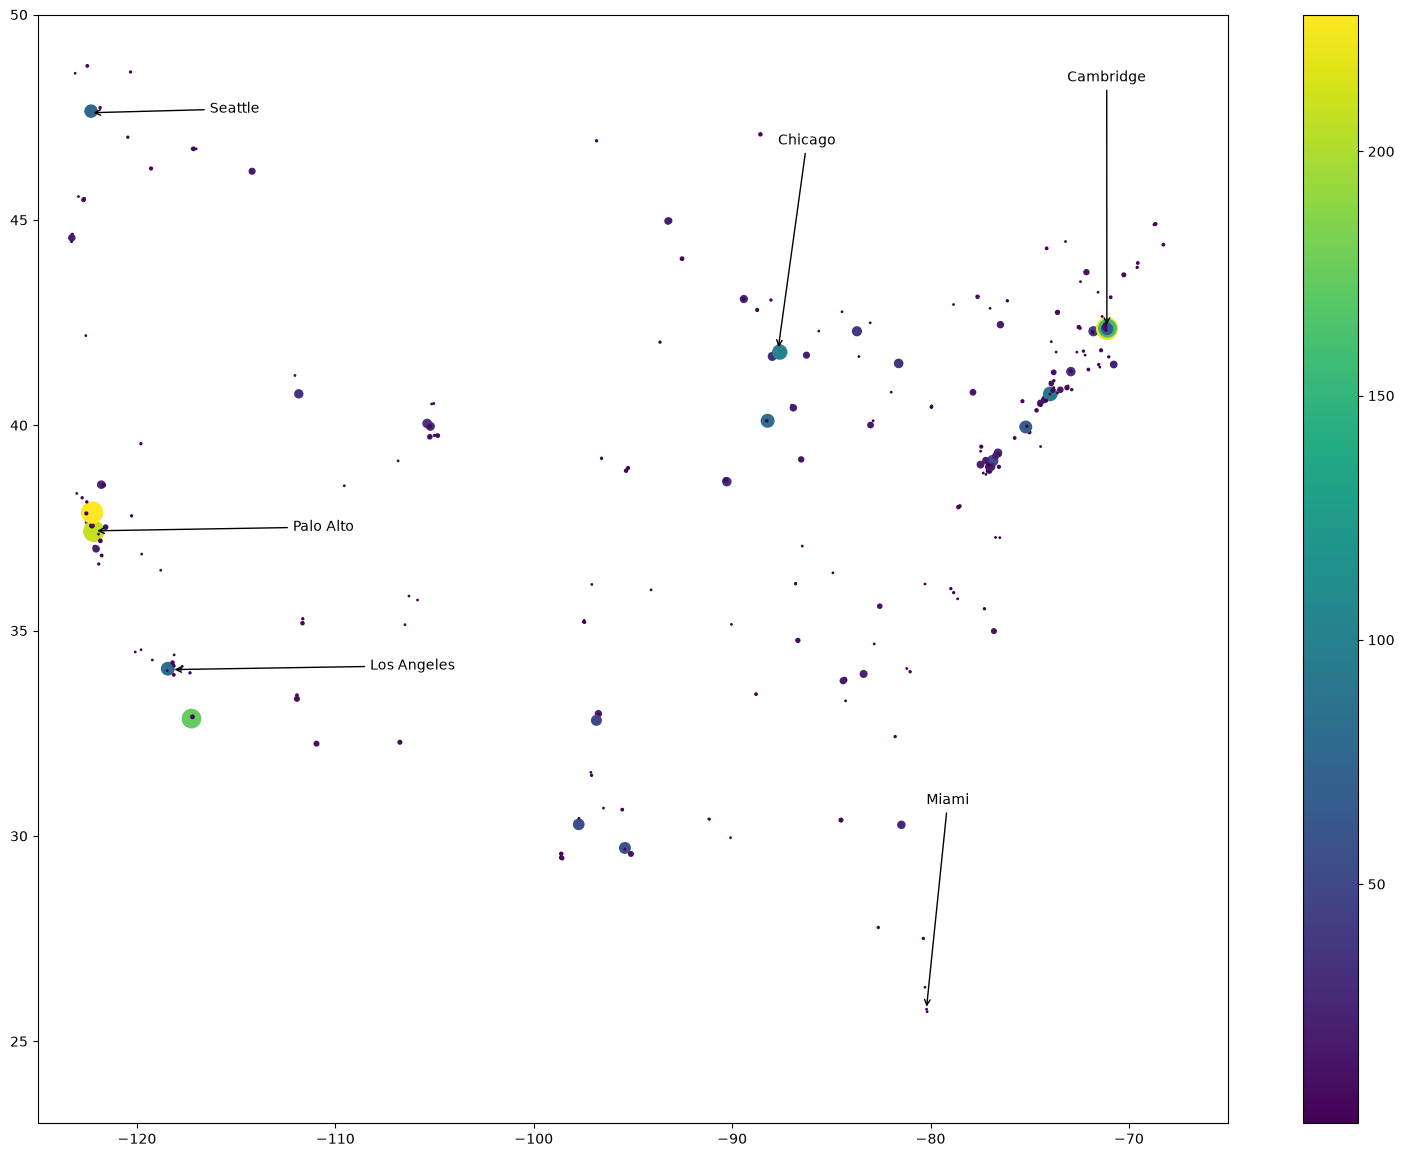

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(zip_long, zip_lat, s=zip_count, c=zip_count)
plt.colorbar()

# only continental us without Alaska
plt.xlim(-125, -65)
plt.ylim(23, 50)

# add a few cities for reference (optional)
ard = dict(arrowstyle="->")
plt.annotate('Los Angeles', xy=(-118.25, 34.05), 
             xytext=(-108.25, 34.05), arrowprops=ard)
plt.annotate('Palo Alto', xy=(-122.1381, 37.4292), 
             xytext=(-112.1381, 37.4292), arrowprops=ard)
plt.annotate('Cambridge', xy=(-71.1106, 42.3736), 
             xytext=(-73.1106, 48.3736), arrowprops=ard)
plt.annotate('Chicago', xy=(-87.6847, 41.8369), 
             xytext=(-87.6847, 46.8369), arrowprops=ard)
plt.annotate('Seattle', xy=(-122.33, 47.61), 
             xytext=(-116.33, 47.61), arrowprops=ard)
plt.annotate('Miami', xy=(-80.21, 25.7753), 
             xytext=(-80.21, 30.7753), arrowprops=ard)

params = plt.gcf()
plSize = params.get_size_inches()
params.set_size_inches((plSize[0] * 3, plSize[1] * 3))

plt.show()